In [9]:
# CNN – Classification d’images (MNIST)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)

# Chargement des données
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisation + ajout du canal (28,28) -> (28,28,1)
X_train = X_train[..., None] / 255.0
X_test = X_test[..., None] / 255.0

def initialize_model():
    model = Sequential([

        # Bloc convolution 1
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        # Bloc convolution 2
        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        # Classification
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Initialisation
model = initialize_model()
model.summary()

c:\Users\darla\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

In [10]:
# Entraînement
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9220 - loss: 0.2606 - val_accuracy: 0.9520 - val_loss: 0.1516
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9730 - loss: 0.0918 - val_accuracy: 0.9887 - val_loss: 0.0403
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9796 - loss: 0.0698 - val_accuracy: 0.9898 - val_loss: 0.0394
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9831 - loss: 0.0578 - val_accuracy: 0.9907 - val_loss: 0.0426
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9859 - loss: 0.0461 - val_accuracy: 0.9913 - val_loss: 0.0393
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9876 - loss: 0.0411 - val_accuracy: 0.9907 - val_loss: 0.0396
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9892 - loss: 0.0347 - val_accuracy: 0.9915 - val_loss: 0.0372
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9886 - loss: 0.0349 - 

In [11]:
# Évaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy sur le jeu de test : {test_accuracy:.4f}")

Accuracy sur le jeu de test : 0.9915


In [12]:
import numpy as np

prediction = model.predict(X_test[:1])
print("Chiffre prédit :", np.argmin(prediction))
print("Chiffre réel  :", y_test[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Chiffre prédit : 6
Chiffre réel  : 7


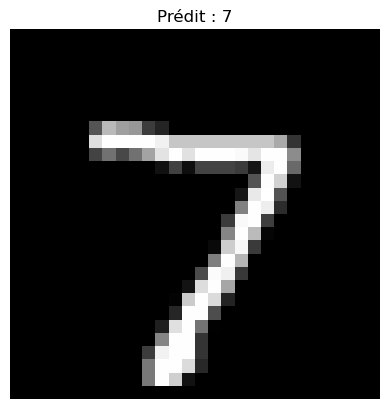

In [13]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0].squeeze(), cmap='gray')
plt.title(f"Prédit : {np.argmax(prediction)}")
plt.axis('off')
plt.show()